In [1]:
import os
import subprocess
try:
    _printenv = subprocess.run(
        ['bash', '-c', 'source ~/.bashrc 2>/dev/null && printenv'],
        text=True, capture_output=True, timeout=10,
    ).stdout
    for _line in _printenv.splitlines():
        if '=' in _line:
            _k, _v = _line.split('=', 1)
            os.environ.setdefault(_k, _v)
except Exception:
    pass
if 'PDK_ROOT' in os.environ and 'PDK' in os.environ:
    os.environ.setdefault('PDKPATH', os.path.join(os.environ['PDK_ROOT'], os.environ['PDK']))

import gdstk
import svgutils.transform as sg
import IPython.display
from IPython.display import clear_output
import ipywidgets as widgets

# Redirect all outputs here
hide = widgets.Output()

def display_gds(gds_file,path,scale = 3):
  
  # Generate an SVG image
  top_level_cell = gdstk.read_gds(gds_file).top_level()[0]
  top_level_cell.write_svg(os.path.join(path,'out.svg'))
    
  # Scale the image for displaying
  fig = sg.fromfile(os.path.join(path,'out.svg'))
  fig.set_size((str(float(fig.width) * scale), str(float(fig.height) * scale)))
  fig.save(os.path.join(path,'out.svg'))

  # Display the image
  IPython.display.display(IPython.display.SVG(os.path.join(path,'out.svg')))
  os.remove(os.path.join(path,'out.gds'))

def display_component(component,path,scale = 3):
  # Save to a GDS file
  with hide:
    component.write_gds(os.path.join(path,'out.gds'))
  display_gds(os.path.join(path,'out.gds'),path,scale)


# %%
import os
import gdsfactory as gf
from gdsfactory import Component
from glayout import MappedPDK, gf180
from glayout import nmos, pmos
from glayout import via_stack
from glayout import rename_ports_by_orientation
from glayout import tapring
from glayout.primitives.mimcap import mimcap_array
from glayout.routing.straight_route import straight_route
from glayout.routing.c_route import c_route
from glayout.routing.L_route import L_route
from glayout.util.comp_utils import evaluate_bbox, prec_center, prec_ref_center, align_comp_to_port
from glayout.util.port_utils import add_ports_perimeter,print_ports
from glayout.util.snap_to_grid import component_snap_to_grid
from glayout.spice.netlist import Netlist


# Base parameters for PMOS and NMOS
stdp_config = {
    "pdk": gf180,
    "layout_rules": {
        "spacing": gf180.util_max_metal_seperation()+1,
        "routing_metal": "met2",
        "dummy_devices": False,
        "tie_layers": ("met2", "met1"),
        "sd_rmult": 1,
    },
}

nmos_kwargs = {
    "with_tie": True,
    "with_dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2","met1"),
    "dummy_routes": False,
    "with_substrate_tap":False
}

pmos_kwargs = {
    "with_tie": True,
    "dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2","met1"),
    "dummy_routes": False,
    "with_substrate_tap":False
}



In [2]:
pdk = gf180
current_mirror = Component(name="current_mirror")
current_mirror.name = "current_mirror"
rules = stdp_config["layout_rules"]
spacing = rules["spacing"]
tie_layers = rules["tie_layers"]
sd_rmult = rules["sd_rmult"]


#Placement
m1 = nmos(pdk, width=4, length=0.28, with_dummy=(False, False),  tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
m2 = nmos(pdk, width=4, length=4, with_dummy=(False, False),  tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
m3 = pmos(pdk, width=8, length=0.5, with_dummy=(False, False),  tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
m4 = pmos(pdk, width=1.6, length=0.5, with_dummy=(False, False), tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)

m1.name = "M1" 
m2.name = "M2" 
m3.name = "M3" 
m4.name = "M4" 

m1_ref = current_mirror << m1
m2_ref = current_mirror << m2
m3_ref = current_mirror << m3
m4_ref = current_mirror << m4


bottom_row_y = evaluate_bbox(m1)[1]/2 + 4
top_row_y = bottom_row_y + evaluate_bbox(m3)[1]

m1_ref.move((evaluate_bbox(m1)[0]/2,bottom_row_y))
m2_ref.move((m1_ref.xmax + evaluate_bbox(m2_ref)[0]/2 + spacing , bottom_row_y))


m4_ref.move((evaluate_bbox(m1)[0]/2 ,top_row_y ))
m3_ref.move((m4_ref.xmax + evaluate_bbox(m3)[0]/2 + spacing,top_row_y))



2026-08-27 00:57:52.425 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


ComponentReference (parent Component "M3", ports ['multiplier_0_gate_W', 'gate_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_layer_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_via_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_met_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_top_met_W', 'multiplier_0_leftsd_array_row0_col0_bottom_layer_W', 'multiplier_0_leftsd_array_row0_col0_bottom_via_W', 'multiplier_0_leftsd_array_row0_col0_bottom_met_W', 'multiplier_0_leftsd_array_row0_col0_top_met_W', 'multiplier_0_row0_col0_rightsd_array_row1_col0_bottom_layer_W', 'multiplier_0_row0_col0_rightsd_array_row1_col0_bottom_via_W', 'multiplier_0_row0_col0_rightsd_array_row1_col0_bottom_met_W', 'multiplier_0_row0_col0_rightsd_array_row1_col0_top_met_W', 'multiplier_0_leftsd_array_row1_col0_bottom_layer_W', 'multiplier_0_leftsd_array_row1_col0_bottom_via_W', 'multiplier_0_leftsd_array_row1_col0_bottom_met_W', 'multiplier_0_leftsd_array_row1_col0_top_met_W', '

In [3]:
m1.ports

{'multiplier_0_gate_W': {'name': 'multiplier_0_gate_W', 'width': 0.5, 'center': [-0.25, -3.195], 'orientation': 180.0, 'layer': [36, 0], 'port_type': 'electrical'},
 'gate_W': {'name': 'gate_W', 'width': 0.5, 'center': [-0.25, -3.195], 'orientation': 180.0, 'layer': [36, 0], 'port_type': 'electrical'},
 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_layer_W': {'name': 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_layer_W', 'width': 0.36, 'center': [0.39, -1.905], 'orientation': 180.0, 'layer': [22, 0], 'port_type': 'electrical'},
 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_via_W': {'name': 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_via_W', 'width': 0.22, 'center': [0.46, -1.905], 'orientation': 180.0, 'layer': [33, 0], 'port_type': 'electrical'},
 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_met_W': {'name': 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_met_W', 'width': 0.46, 'center': [0.34, -1.905], 'orientation': 180.0, 'la

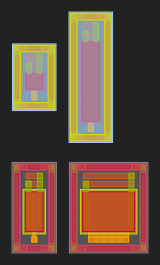

In [4]:
# stdp_comp.show()
display_component(current_mirror, scale = 1,path=".")

In [5]:
## =========================================================================
## 4. ADD AVDD & AVSS POWER RAILS AND CONNECT SUPPLY NODES
## =========================================================================
#
## https://gemini.google.com/app/131a537106def8cd
## Calculate full horizontal span of the cell to draw supply rails
#bbox = evaluate_bbox(current_mirror)
#top_y = current_mirror.ymax + 2.0
#bottom_y = current_mirror.ymin - 2.0
#
## Draw horizontal metal2 power rails
#avdd_rail = current_mirror << gf.components.rectangle(
#    size=(bbox[0]+4, 1.0), 
#    layer=pdk.get_layer("metal2")
#)
#avdd_rail.move((-2, top_y))
#
#avss_rail = current_mirror << gf.components.rectangle(
#    size=(bbox[0]+4, 1.0), 
#    layer=pdk.get_layer("metal2")
#)
#avss_rail.move((-2, bottom_y))
#
#viam2m3 = via_stack(pdk, "met2", "met3", centered=True) #met2 is the bottom layer. met3 is the top layer.
#
##via en vdd
#vdd_via = current_mirror << viam2m3
#vdd_via.move((bbox[0]/2, top_y + 0.5))
#
##via en vss
#vss_via = current_mirror << viam2m3
#vss_via.move((bbox[0]/2, bottom_y + 0.5))
#
## Add global ports for the supply rails
#current_mirror.add_port("vdd", center=(bbox[0]/2, top_y + 0.5), width=1.0, orientation=180, layer=pdk.get_layer("metal3"), port_type="electrical")
#current_mirror.add_port("vss", center=(bbox[0]/2, bottom_y + 0.5), width=1.0, orientation=180, layer=pdk.get_layer("metal3"), port_type="electrical")
#
## add label to those global ports 
#current_mirror.add_label(text="vdd", position=(bbox[0]/2, top_y + 0.5), layer=pdk.get_glayer("met3_label") , magnification=1.1)
#current_mirror.add_label(text="vss", position=(bbox[0]/2, bottom_y + 0.5), layer=pdk.get_glayer("met3_label") , magnification=1.1)
#

In [6]:
# =========================================================================
# 4. ADD AVDD & AVSS POWER RAILS AND CONNECT SUPPLY NODES
# =========================================================================

bbox = evaluate_bbox(current_mirror)
top_y = current_mirror.ymax + 2.0
bottom_y = current_mirror.ymin - 2.0

# Draw horizontal metal2 power rails
avdd_rail = current_mirror << gf.components.rectangle(
    size=(bbox[0]+4, 1.0), 
    layer=pdk.get_layer("metal2")
)
avdd_rail.move((-2, top_y))

avss_rail = current_mirror << gf.components.rectangle(
    size=(bbox[0]+4, 1.0), 
    layer=pdk.get_layer("metal2")
)
avss_rail.move((-2, bottom_y))

# Crear vias internas (nodos de conexión)
viam2m3 = via_stack(pdk, "met2", "met3", centered=True)

# Vía en VDD (nodo interno, no global port)
vdd_via = current_mirror << viam2m3
vdd_via.move((bbox[0]/2, top_y + 0.5))

# Vía en VSS (nodo interno, no global port)
vss_via = current_mirror << viam2m3
vss_via.move((bbox[0]/2, bottom_y + 0.5))



ComponentReference (parent Component "via_stack_a2e89513", ports ['bottom_layer_W', 'bottom_layer_N', 'bottom_layer_E', 'bottom_layer_S', 'bottom_via_W', 'bottom_via_N', 'bottom_via_E', 'bottom_via_S', 'bottom_met_W', 'bottom_met_N', 'bottom_met_E', 'bottom_met_S', 'top_met_W', 'top_met_N', 'top_met_E', 'top_met_S'], origin (6.8, 2.5), rotation 0.0, x_reflection False)

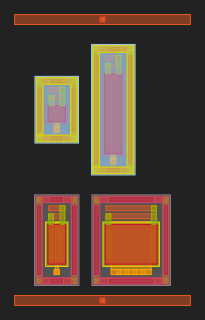

In [7]:
# stdp_comp.show()
display_component(current_mirror, scale = 1,path=".")

In [8]:
# =========================================================================
# 1. Crear rieles horizontales en Metal5 (VDD interior y VSS exterior)
# =========================================================================

bbox = evaluate_bbox(current_mirror)

# Coordenadas base
top_y = current_mirror.ymax + 0.0
bottom_y = current_mirror.ymin - 0.0

rail_width = 6.0   # ancho del riel
rail_margin_vdd = 5.0  # sobresalir 5 µm a cada lado (VDD)
rail_margin_vss = 14.0  # sobresalir 14 µm a cada lado (VSS)
rail_sep = 2.0     # separación entre anillos

# Longitudes
rail_length_vdd = bbox[0] + 2*rail_margin_vdd
rail_length_vss = bbox[0] + 2*rail_margin_vss

# --- Rieles superiores ---
# VDD (interior)
vdd_top = current_mirror << gf.components.rectangle(
    size=(rail_length_vdd, rail_width),
    layer=pdk.get_layer("metal5")
)
vdd_top.move((-rail_margin_vdd, top_y + rail_sep))

# --- Etiqueta para riel superior VDD ---
vdd_top_label = current_mirror << gf.components.rectangle(
    size=(rail_length_vdd, rail_width),
    layer=pdk.get_layer("metal5_label")   # capa de etiqueta asociada a metal5
)
vdd_top_label.move((-rail_margin_vdd, top_y + rail_sep))
# Añadir nombre de la red (avdd) a la etiqueta
current_mirror.add_label(
    text="avdd",
    position=(bbox[0]/2, top_y + rail_sep + rail_width/2),  # centrado en el riel
    layer=pdk.get_layer("metal5_label"),
    magnification=1.2
)

# VSS (exterior)
vss_top = current_mirror << gf.components.rectangle(
    size=(rail_length_vss, rail_width),
    layer=pdk.get_layer("metal5")
)
vss_top.move((-rail_margin_vss, top_y + rail_sep + rail_width + rail_sep))

# --- Etiqueta para riel superior VSS ---
vss_top_label = current_mirror << gf.components.rectangle(
    size=(rail_length_vss, rail_width),
    layer=pdk.get_layer("metal5_label")   # capa de etiqueta asociada a metal5
)
vss_top_label.move((-rail_margin_vss, top_y + rail_sep + rail_width + rail_sep))

# Añadir nombre de la red (avss) a la etiqueta
current_mirror.add_label(
    text="avss",
    position=(bbox[0]/2, top_y + rail_sep + rail_width + rail_sep + rail_width/2),  # centrado en el riel
    layer=pdk.get_layer("metal5_label"),
    magnification=1.2
)



# --- Rieles inferiores ---
# VDD (interior)
vdd_bot = current_mirror << gf.components.rectangle(
    size=(rail_length_vdd, rail_width),
    layer=pdk.get_layer("metal5")
)
vdd_bot.move((-rail_margin_vdd, bottom_y - rail_sep - rail_width))

# --- Etiqueta para riel inferior VDD ---
vdd_bot_label = current_mirror << gf.components.rectangle(
    size=(rail_length_vdd, rail_width),
    layer=pdk.get_layer("metal5_label")   # capa de etiqueta asociada a metal5
)
vdd_bot_label.move((-rail_margin_vdd, bottom_y - rail_sep - rail_width))

# Añadir nombre de la red (avdd) a la etiqueta
current_mirror.add_label(
    text="avdd",
    position=(bbox[0]/2, bottom_y - rail_sep - rail_width/2),  # centrado en el riel
    layer=pdk.get_layer("metal5_label"),
    magnification=1.2
)


# VSS (exterior)
vss_bot = current_mirror << gf.components.rectangle(
    size=(rail_length_vss, rail_width),
    layer=pdk.get_layer("metal5")
)
vss_bot.move((-rail_margin_vss, bottom_y - 2*rail_sep - 2*rail_width))

# --- Etiqueta para riel inferior VSS ---
vss_bot_label = current_mirror << gf.components.rectangle(
    size=(rail_length_vss, rail_width),
    layer=pdk.get_layer("metal5_label")   # capa de etiqueta asociada a metal5
)
vss_bot_label.move((-rail_margin_vss, bottom_y - 2*rail_sep - 2*rail_width))

# Añadir nombre de la red (avss) a la etiqueta
current_mirror.add_label(
    text="avss",
    position=(bbox[0]/2, bottom_y - 2*rail_sep - 2*rail_width + rail_width/2),  # centrado en el riel
    layer=pdk.get_layer("metal5_label"),
    magnification=1.2
)


# =========================================================================
# 2. Crear vias para conectar los rieles de Metal5 a los rieles de Metal4
# =========================================================================

# Crear vía M5 → M4 en el riel superior VSS (esquina superior izquierda)
viam5m4 = via_stack(pdk, "met5", "met4", centered=True)

# Coordenadas del riel superior VSS
vss_top_bbox = evaluate_bbox(vss_top)  # ancho y alto del rectángulo VSS
vss_top_xmin = -rail_margin_vss        # inicio en X del riel
vss_top_y = top_y + rail_sep + rail_width + rail_sep  # posición Y del riel

# Colocar vía: 3 µm hacia adentro desde el inicio del riel
via_vss_top_left = current_mirror << viam5m4
via_vss_top_left.move((
    vss_top_xmin + 3.0,                # 3 µm hacia adentro
    vss_top_y + rail_width/2           # centrado en Y del riel
))

# Crear vía M5 → M4 en el riel superior VSS (esquina superior derecha)
viam5m4 = via_stack(pdk, "met5", "met4", centered=True)

# Coordenadas del riel superior VSS
vss_top_xmax = bbox[0] + rail_margin_vss   # extremo derecho del riel
vss_top_y = top_y + rail_sep + rail_width + rail_sep  # posición Y del riel

# Colocar vía: 3 µm hacia adentro desde el extremo derecho
via_vss_top_right = current_mirror << viam5m4
via_vss_top_right.move((
    vss_top_xmax - 3.0,               # 3 µm hacia adentro desde el extremo derecho
    vss_top_y + rail_width/2          # centrado en Y del riel
))

# Crear vía M5 → M4 en el riel inferior VSS (esquina inferior izquierda)
viam5m4 = via_stack(pdk, "met5", "met4", centered=True)

# Coordenadas del riel inferior VSS
vss_bot_xmin = -rail_margin_vss
vss_bot_xmax = bbox[0] + rail_margin_vss
vss_bot_y = bottom_y - 2*rail_sep - 2*rail_width

# Vía esquina inferior izquierda
via_vss_bot_left = current_mirror << viam5m4
via_vss_bot_left.move((
    vss_bot_xmin + 3.0,               # 3 µm hacia adentro desde el inicio izquierdo
    vss_bot_y + rail_width/2          # centrado en Y del riel
))

# Vía esquina inferior derecha
via_vss_bot_right = current_mirror << viam5m4
via_vss_bot_right.move((
    vss_bot_xmax - 3.0,               # 3 µm hacia adentro desde el extremo derecho
    vss_bot_y + rail_width/2          # centrado en Y del riel
))

# Crear vías M5 → M4 en los rieles de VDD (anillo interior)
viam5m4 = via_stack(pdk, "met5", "met4", centered=True)

# Coordenadas del riel superior VDD
vdd_top_xmin = -rail_margin_vdd
vdd_top_xmax = bbox[0] + rail_margin_vdd
vdd_top_y = top_y + rail_sep

# Esquina superior izquierda
via_vdd_top_left = current_mirror << viam5m4
via_vdd_top_left.move((
    vdd_top_xmin + 3.0,
    vdd_top_y + rail_width/2
))

# Esquina superior derecha
via_vdd_top_right = current_mirror << viam5m4
via_vdd_top_right.move((
    vdd_top_xmax - 3.0,
    vdd_top_y + rail_width/2
))

# Coordenadas del riel inferior VDD
vdd_bot_xmin = -rail_margin_vdd
vdd_bot_xmax = bbox[0] + rail_margin_vdd
vdd_bot_y = bottom_y - rail_sep - rail_width

# Esquina inferior izquierda
via_vdd_bot_left = current_mirror << viam5m4
via_vdd_bot_left.move((
    vdd_bot_xmin + 3.0,
    vdd_bot_y + rail_width/2
))

# Esquina inferior derecha
via_vdd_bot_right = current_mirror << viam5m4
via_vdd_bot_right.move((
    vdd_bot_xmax - 3.0,
    vdd_bot_y + rail_width/2
))


# =========================================================================
# Rieles verticales Metal4
# =========================================================================

rail_width_m4 = 5.0  # ancho del riel vertical

# Coordenadas de los rieles VSS
vss_top_y = top_y + rail_sep + rail_width + rail_sep
vss_bot_y = bottom_y - 2*rail_sep - 2*rail_width

# Altura total del riel vertical
rail_height_vss = (vss_top_y - vss_bot_y) + rail_width

# Crear rectángulo vertical en Metal4
vss_left_m4 = current_mirror << gf.components.rectangle(
    size=(rail_width_m4, rail_height_vss),
    layer=pdk.get_layer("metal4")
)

# Posicionar: justo debajo del borde izquierdo del riel VSS
vss_left_m4.move((
    -rail_margin_vss,   # borde izquierdo del riel VSS
    vss_bot_y           # desde la parte inferior del riel inferior
))

# --- Etiqueta para riel vertical izquierdo VSS ---
vss_left_label_m4 = current_mirror << gf.components.rectangle(
    size=(rail_width_m4, rail_height_vss),
    layer=pdk.get_layer("metal4_label")   # capa de etiqueta asociada a metal4
)
vss_left_label_m4.move((
    -rail_margin_vss,   # borde izquierdo del riel VSS
    vss_bot_y           # desde la parte inferior del riel inferior
))

# Añadir nombre de la red (avss) centrado en el riel vertical
current_mirror.add_label(
    text="avss",
    position=(-rail_margin_vss + rail_width_m4/2, vss_bot_y + rail_height_vss/2),  # centro del rectángulo
    layer=pdk.get_layer("metal4_label"),
    magnification=1.2
)



# Riel derecho VSS

rail_width_m4 = 5.0  # ancho del riel vertical

# Coordenadas de los rieles VSS
vss_top_y = top_y + rail_sep + rail_width + rail_sep
vss_bot_y = bottom_y - 2*rail_sep - 2*rail_width

# Altura total del riel vertical
rail_height_vss = (vss_top_y - vss_bot_y) + rail_width

# Crear rectángulo vertical en Metal4 (lado derecho)
vss_right_m4 = current_mirror << gf.components.rectangle(
    size=(rail_width_m4, rail_height_vss),
    layer=pdk.get_layer("metal4")
)

# Posicionar: justo en el borde derecho del riel VSS
vss_right_m4.move((
    bbox[0] + rail_margin_vss - rail_width_m4,  # borde derecho menos el ancho del riel
    vss_bot_y                                  # desde la parte inferior del riel inferior
))

# --- Etiqueta para riel vertical derecho VSS ---
vss_right_label_m4 = current_mirror << gf.components.rectangle(
    size=(rail_width_m4, rail_height_vss),
    layer=pdk.get_layer("metal4_label")   # capa de etiqueta asociada a metal4
)
vss_right_label_m4.move((
    bbox[0] + rail_margin_vss - rail_width_m4,  # borde derecho menos el ancho del riel
    vss_bot_y                                  # desde la parte inferior del riel inferior
))

# Añadir nombre de la red (avss) centrado en el riel vertical
current_mirror.add_label(
    text="avss",
    position=(bbox[0] + rail_margin_vss - rail_width_m4/2, vss_bot_y + rail_height_vss/2),  # centro del rectángulo
    layer=pdk.get_layer("metal4_label"),
    magnification=1.2
)


# Rieles de vdd

rail_width_m4 = 5.0  # ancho del riel vertical

# Coordenadas de los rieles VDD
vdd_top_y = top_y + rail_sep
vdd_bot_y = bottom_y - rail_sep - rail_width

# Altura total del riel vertical
rail_height_vdd = (vdd_top_y - vdd_bot_y) + rail_width

# --- Riel vertical izquierdo VDD ---
vdd_left_m4 = current_mirror << gf.components.rectangle(
    size=(rail_width_m4, rail_height_vdd),
    layer=pdk.get_layer("metal4")
)
vdd_left_m4.move((
    -rail_margin_vdd,   # borde izquierdo del riel VDD
    vdd_bot_y           # desde la parte inferior del riel inferior
))

# --- Etiqueta para riel vertical izquierdo VDD ---
vdd_left_label_m4 = current_mirror << gf.components.rectangle(
    size=(rail_width_m4, rail_height_vdd),
    layer=pdk.get_layer("metal4_label")   # capa de etiqueta asociada a metal4
)
vdd_left_label_m4.move((
    -rail_margin_vdd,   # borde izquierdo del riel VDD
    vdd_bot_y           # desde la parte inferior del riel inferior
))

# Añadir nombre de la red (avdd) centrado en el riel vertical
current_mirror.add_label(
    text="avdd",
    position=(-rail_margin_vdd + rail_width_m4/2, vdd_bot_y + rail_height_vdd/2),  # centro del rectángulo
    layer=pdk.get_layer("metal4_label"),
    magnification=1.2
)

# --- Riel vertical derecho VDD ---
vdd_right_m4 = current_mirror << gf.components.rectangle(
    size=(rail_width_m4, rail_height_vdd),
    layer=pdk.get_layer("metal4")
)
vdd_right_m4.move((
    bbox[0] + rail_margin_vdd - rail_width_m4,  # borde derecho menos ancho del riel
    vdd_bot_y
))

# --- Etiqueta para riel vertical derecho VDD ---
vdd_right_label_m4 = current_mirror << gf.components.rectangle(
    size=(rail_width_m4, rail_height_vdd),
    layer=pdk.get_layer("metal4_label")   # capa de etiqueta asociada a metal4
)
vdd_right_label_m4.move((
    bbox[0] + rail_margin_vdd - rail_width_m4,  # borde derecho menos ancho del riel
    vdd_bot_y
))

# Añadir nombre de la red (avdd) centrado en el riel vertical
current_mirror.add_label(
    text="avdd",
    position=(bbox[0] + rail_margin_vdd - rail_width_m4/2, vdd_bot_y + rail_height_vdd/2),  # centro del rectángulo
    layer=pdk.get_layer("metal4_label"),
    magnification=1.2
)



Label(text='avdd', origin=(20.1, 16.59), layer=(46, 10))

In [9]:
# =========================================================================
# Conexión del nodo VDD existente hacia el anillo AVDD
# =========================================================================

current_mirror << straight_route(
    pdk,
    vdd_via.ports["top_met_S"],             # salida norte del nodo vdd
    via_vdd_top_right.ports["bottom_met_N"],# entrada sur de la vía avdd
    glayer1="met3",
    glayer2="met5",
    width=rail_width_m4
)

# =========================================================================
# Conexión del nodo VSS existente hacia el anillo AVSS
# =========================================================================

# Conexión en Metal3 hasta la posición del anillo
current_mirror << straight_route(
    pdk,
    vss_via.ports["top_met_N"],              # salida sur del nodo vss en Metal3
    via_vss_bot_right.ports["bottom_met_S"], # entrada norte de la vía avss
    glayer1="met3",                          # tramo largo en Metal3
    glayer2="met5",                          # al llegar sube a Metal5
    width=rail_width
)



ComponentReference (parent Component "straight_route_5f260ded", ports ['route_W', 'route_N', 'route_E', 'route_S'], origin (0.0, 0.0), rotation 0.0, x_reflection False)

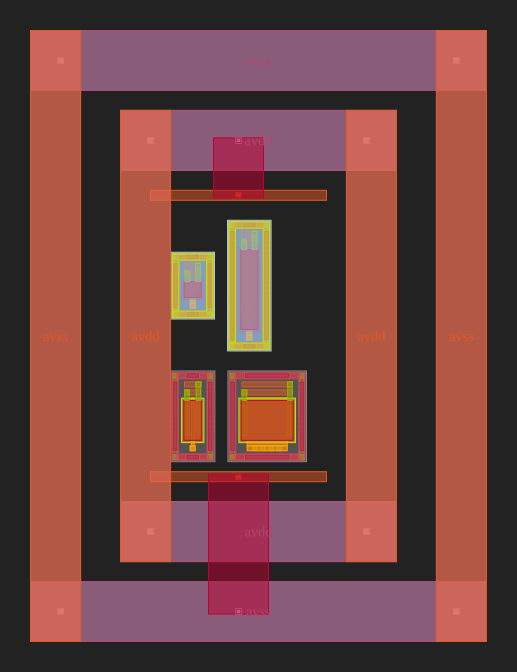

In [10]:
# stdp_comp.show()
display_component(current_mirror, scale = 1,path=".")

In [11]:
#Adding VIAS
viam2m3 = via_stack(pdk, "met2", "met3", centered=True) #met2 is the bottom layer. met3 is the top layer.
node_A_via = current_mirror << viam2m3
node_A_via_2 = current_mirror << viam2m3

node_A_via.move(m4_ref.ports["gate_S"].center).movex(2.8).movey(-5)
node_A_via_2.move(m4_ref.ports["gate_S"].center).movex(-2.5).movey(-5)

node_B_via = current_mirror << viam2m3
node_B_via.move(m3_ref.ports["gate_S"].center).movex(2.8).movey(-2)


ComponentReference (parent Component "via_stack_a2e89513$1", ports ['bottom_layer_W', 'bottom_layer_N', 'bottom_layer_E', 'bottom_layer_S', 'bottom_via_W', 'bottom_via_N', 'bottom_via_E', 'bottom_via_S', 'bottom_met_W', 'bottom_met_N', 'bottom_met_E', 'bottom_met_S', 'top_met_W', 'top_met_N', 'top_met_E', 'top_met_S'], origin (10.68, 14.189999999999998), rotation 0.0, x_reflection False)

In [12]:
# =========================================================================
# 5. ADD MET2 PHYSICAL PINS AND LABELS FOR LVS
# =========================================================================

# Map port names to their source port objects
pins_to_create = {
    "A": node_A_via.ports["top_met_N"],
    "B": node_B_via.ports["top_met_N"]
}

for pin_name, port in pins_to_create.items():
    # Extract center position, size, and orientation from port object
    center = port.center
    width = port.width
    height = port.width  # Standard square pin area around the port center

    # 1. Add pin rectangle shape on met2_pin
    pin_ref = current_mirror << gf.components.rectangle(
        size = (width,height),
        layer=pdk.get_layer("metal3")
    )
    pin_ref.move((center[0] - width , center[1] - height))
    
    current_mirror.add_port(pin_name, center=(center[0] - width , center[1] - height), width=1.0, orientation=180, layer=pdk.get_layer("metal3"),  port_type="electrical") 

    # 2. Add text label on met2_pin layer for net identity
    current_mirror.add_label(
        text=pin_name, position=(center[0] - width , center[1] - height), layer=pdk.get_glayer("met3_label"), magnification=1.2
    )
   

In [13]:
# Connect PMOS bulks to vdd rail
current_mirror << L_route(pdk, m4_ref.ports["tie_W_top_met_N"], vdd_via.ports["bottom_met_W"])
current_mirror << L_route(pdk, m3_ref.ports["tie_W_top_met_N"], vdd_via.ports["bottom_met_W"])

# Connect NMOS BULKS TO VSS
current_mirror << L_route(pdk, m1_ref.ports["tie_W_top_met_S"], vss_via.ports["bottom_met_W"])
current_mirror << L_route(pdk, m2_ref.ports["tie_W_top_met_S"], vss_via.ports["bottom_met_W"])

#connecting PMOS SOURCES TO VDD
current_mirror << L_route(pdk,  m4_ref.ports["multiplier_0_source_E"], m4_ref.ports["tie_E_top_met_N"])  # SOURCE m4
current_mirror << L_route(pdk,  m3_ref.ports["multiplier_0_source_E"], m3_ref.ports["tie_E_top_met_N"])  # SOURCE M3

#CONNECTING NMOS SOURCE TO VSS
current_mirror << L_route(pdk,  m1_ref.ports["multiplier_0_source_E"], m1_ref.ports["tie_E_top_met_N"]) #m1
current_mirror << L_route(pdk,  m2_ref.ports["multiplier_0_source_E"], m2_ref.ports["tie_E_top_met_N"]) #m2

ComponentReference (parent Component "L_route_2ca5f29d", ports ['bottom_layer_W', 'bottom_via_W', 'bottom_met_W', 'top_met_W', 'bottom_layer_N', 'bottom_via_N', 'bottom_met_N', 'top_met_N', 'bottom_layer_E', 'bottom_via_E', 'bottom_met_E', 'top_met_E', 'bottom_layer_S', 'bottom_via_S', 'bottom_met_S', 'top_met_S'], origin (0.0, 0.0), rotation 0.0, x_reflection False)

In [14]:
#NODE A

current_mirror << L_route(pdk, m4_ref.ports["drain_W"], node_A_via_2.ports["top_met_N"])
current_mirror << L_route(pdk, m1_ref.ports["drain_W"], node_A_via_2.ports["top_met_S"])
current_mirror << L_route(pdk, m4_ref.ports["gate_W"], node_A_via_2.ports["top_met_N"])
current_mirror << L_route(pdk, m1_ref.ports["gate_W"], node_A_via_2.ports["top_met_S"])
current_mirror << straight_route(pdk, node_A_via_2.ports["bottom_met_W"], node_A_via.ports["bottom_met_E"])
current_mirror << L_route(pdk, m2_ref.ports["gate_W"], node_A_via.ports["top_met_S"])

#NODE B
current_mirror << c_route(pdk, m3_ref.ports["drain_E"], node_B_via.ports["bottom_met_E"])
current_mirror << c_route(pdk, m3_ref.ports["gate_E"], node_B_via.ports["bottom_met_E"])
current_mirror << c_route(pdk, m2_ref.ports["drain_W"], node_B_via.ports["bottom_met_W"])


ComponentReference (parent Component "c_route_4bda49c0", ports ['con_N', 'con_S'], origin (0.0, 0.0), rotation 0.0, x_reflection False)

2026-08-27 00:57:57.163 | WARNING  | gdsfactory.klive:show:48 - Could not connect to klive server. Is klayout open and klive plugin installed?


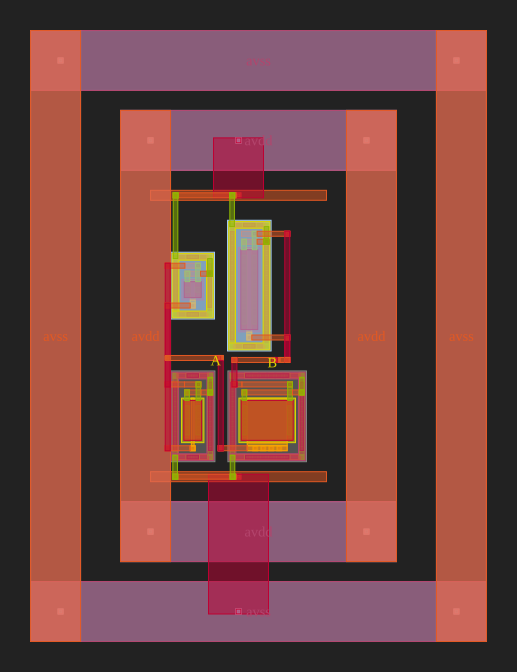

In [15]:
current_mirror.show()
display_component(current_mirror, scale = 1,path=".")

In [16]:
# ----------- adding a full rectangle in metal (0/0) ---------------------
full_rect_00 = current_mirror << gf.components.rectangle(
    size=evaluate_bbox(current_mirror), 
    layer=(0, 0)
)
#moviendo a las coordenadas 0,0 del layout
full_rect_00.move((current_mirror.xmin, current_mirror.ymin))

ComponentReference (parent Component "rectangle_7893d90a", ports ['e1', 'e2', 'e3', 'e4'], origin (-14.0, -14.0), rotation 0.0, x_reflection False)

2026-08-27 00:57:57.356 | WARNING  | gdsfactory.klive:show:48 - Could not connect to klive server. Is klayout open and klive plugin installed?


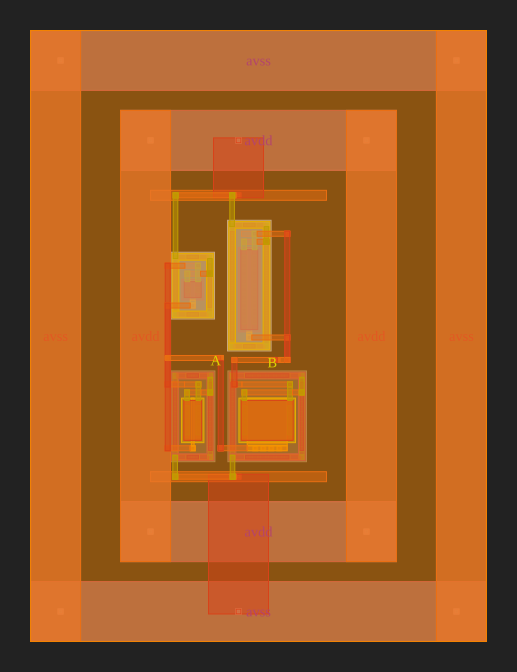

In [17]:
current_mirror.show()
display_component(current_mirror, scale = 1,path=".")

In [18]:
current_mirror.pprint_ports()

┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┓
┃ name ┃ width ┃ center         ┃ orientation ┃ layer   ┃ port_type  ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━┩
│ A    │ 1.0   │ [4.52, 14.14]  │ 180         │ [42, 0] │ electrical │
│ B    │ 1.0   │ [10.18, 13.94] │ 180         │ [42, 0] │ electrical │
└──────┴───────┴────────────────┴─────────────┴─────────┴────────────┘

In [19]:
evaluate_bbox(current_mirror)

(45.6, 61.18)

In [20]:
current_mirror_est_area = evaluate_bbox(current_mirror)[0] * evaluate_bbox(current_mirror)[1]
current_mirror_est_area

2789.808

In [21]:
m1_ref.info['netlist'].generate_netlist()

'\n\n.subckt NMOS D G S B DUM l=0.28 w=4\nXMAIN1 D G S B nfet_03v3 l=0.28 w=4\n.ends NMOS'

In [22]:
# netlist = Netlist(circuit_name="current_mirror", nodes=['avss', 'avdd', 'B', 'A'])
# netlist.connect_netlist(m1_ref.info['netlist'], [('D', 'A'),   ('G', 'A'),   ('S', 'avss'), ('B', 'avss')])
# netlist.connect_netlist(m2_ref.info['netlist'], [('D', 'B'),   ('G', 'A'),   ('S', 'avss'), ('B', 'avss')])
# netlist.connect_netlist(m3_ref.info['netlist'], [('D', 'B'),   ('G', 'B'),   ('S', 'avdd'), ('B', 'avdd')])
# netlist.connect_netlist(m4_ref.info['netlist'], [('D', 'A'),   ('G', 'A'),   ('S', 'avdd'), ('B', 'avdd')])

# current_mirror.info["netlist"] = netlist
# print(current_mirror.info['netlist'].generate_netlist())

In [23]:
import os
from pathlib import Path
import tempfile

path_to_dir = "/foss/designs/libs/snn_analog/current_mirror/"
# path_to_dir = "/foss/designs/libs/snn_analog/current_mirror/"
magicrc_file = Path(os.environ['PDKPATH']) / "libs.tech" / "magic" / f"{os.environ['PDK']}.magicrc"
design_name=current_mirror.name

pex_path = path_to_dir + f"{current_mirror.name}.spice"
gds_path = path_to_dir + f"{current_mirror.name}.gds"
current_mirror.write_gds(str(gds_path))


magic_script_content = f"""
drc off            
gds flatglob *\\$\\$*
gds read {gds_path}

flatten {design_name}
load {design_name}
select top cell
extract do local
extract all
ext2sim labels on
ext2sim
extresist tolerance 10
extresist
ext2spice lvs
ext2spice cthresh 0
ext2spice extresist on
ext2spice -o {str(pex_path)}
exit
"""

with tempfile.NamedTemporaryFile(mode='w', delete=False) as magic_script_file:
    magic_script_file.write(magic_script_content)
    magic_script_path = magic_script_file.name
    
magic_cmd = f"bash -c 'magic -rcfile {magicrc_file} -noconsole -dnull < {magic_script_path}'",
magic_subproc = subprocess.run(
    magic_cmd, 
    shell=True,
    check=True,
    capture_output=True
)

magic_subproc_code = magic_subproc.returncode
magic_subproc_out = magic_subproc.stdout.decode('utf-8')
print(magic_subproc_out)




2026-08-27 00:57:58.163 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/foss/designs/libs/snn_analog/current_mirror/current_mirror.gds'



Magic 8.3 revision 636 - Compiled on Thu Apr 16 09:13:57 PM CEST 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Using technology "gf180mcuD", version 1.0.575-2-g7b70722
Library written using GDS-II Release 6.0
Library name: library
Reading "current_mirror".
Reading "via_stack_a2

In [24]:
drc_result = gf180.drc_magic(current_mirror, current_mirror.name)

2026-08-27 00:57:59.197 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpelrv6_dx/current_mirror.gds'


using default pdk_root
Defaulting to stale magic_commands.tcl

Magic 8.3 revision 636 - Compiled on Thu Apr 16 09:13:57 PM CEST 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmpelrv6_dx/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0

In [25]:
import glob
extensions = [
            "els"
            "*.gds",
            "*.ext",
            "*.res.ext",
            "*.lvs.rpt",
            "*_lvs.rpt",
            "*.nodes",
            "*.sim",
            "*.pex.spice",
            "*_pex.spice"
            ]
files_to_delete = []
for ext in extensions:
    files_to_delete.extend(glob.glob(ext))
    
# Delete the files
for file_path in files_to_delete:
    try:
        os.remove(file_path)
        print(f"Deleted: {file_path}")
    except OSError as e:
        print(f"Error deleting {file_path}: {e}")

Deleted: compass_0890f839$1.ext
Deleted: compass_0890f839.ext
Deleted: compass_09765aef$1.ext
Deleted: compass_09765aef.ext
Deleted: compass_2d1cdd23$4.ext
Deleted: compass_2d1cdd23$5.ext
Deleted: compass_419645f2$1.ext
Deleted: compass_419645f2.ext
Deleted: compass_440c9197$1.ext
Deleted: compass_440c9197.ext
Deleted: compass_76be499d$1.ext
Deleted: compass_76be499d.ext
Deleted: compass_b1b70d86$1.ext
Deleted: compass_b1b70d86.ext
Deleted: compass_c280ddcc$1.ext
Deleted: compass_c280ddcc.ext
Deleted: compass_efcb33f4$1.ext
Deleted: compass_efcb33f4.ext
Deleted: compass_f95d80a2$1.ext
Deleted: compass_f95d80a2.ext
Deleted: current_mirror.ext
Deleted: current_mirror.res.ext
Deleted: c_route_2703b2bc.ext
Deleted: c_route_4bda49c0.ext
Deleted: c_route_d401f779.ext
Deleted: L_route_0f61577c.ext
Deleted: L_route_114e638b.ext
Deleted: L_route_2ca5f29d.ext
Deleted: L_route_32443274.ext
Deleted: L_route_3bbfb944.ext
Deleted: L_route_3fc55cb2.ext
Deleted: L_route_3ff8ec8b.ext
Deleted: L_route_6

In [26]:
gf180.lvs_netgen(
    layout=current_mirror,
    design_name = str(current_mirror.name),
    pdk_root = Path(os.environ['PDKPATH']),
    lvs_setup_tcl_file = Path(os.environ['PDKPATH']) / "libs.tech" / "netgen" / f"{os.environ['PDK']}_setup.tcl",
    lvs_schematic_ref_file = Path(str(path_to_dir + "current_mirror.spice")),
    netlist = Path(str(path_to_dir + "current_mirror_sch.spice")),
    output_file_path =  Path(str(path_to_dir))
)


2026-08-27 00:57:59.861 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpwrcax48n/current_mirror.gds'


using user specified pdk_root, will search for required files in the specified directory

Magic 8.3 revision 636 - Compiled on Thu Apr 16 09:13:57 PM CEST 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Using technology "gf180mcuD", version 1.0.575-2-g7b70722
Library written using

PermissionError: [Errno 1] Operation not permitted: '/foss/designs/libs/snn_analog/current_mirror/lvs/current_mirror/current_mirror_lvs.rpt'

In [27]:
from pathlib import Path
import os
import subprocess

pdk_name = os.environ.get("PDK", "gf180mcuD")
pdk_root = Path(os.environ.get("PDK_ROOT", ""))
pdk_path_env = Path(os.environ.get("PDKPATH", ""))

# Resolve the correct magicrc path even if PDKPATH is stale or duplicated.
candidate_pdkpaths = [
    pdk_path_env,
    pdk_root / pdk_name,
    pdk_root,
]
magicrc_file = None
for candidate in candidate_pdkpaths:
    if not str(candidate):
        continue
    rc = candidate / "libs.tech" / "magic" / f"{pdk_name}.magicrc"
    if rc.exists():
        magicrc_file = rc
        break

if magicrc_file is None:
    raise FileNotFoundError(
        "No se encontro el magicrc. Revisar PDK_ROOT/PDK/PDKPATH. "
        f"Busque en: {[str(c) for c in candidate_pdkpaths if str(c)]}"
    )

# --- Cambio clave: usar path_to_dir en vez de Path.cwd()/"exports" --
output_dir = Path(path_to_dir)
output_dir.mkdir(parents=True, exist_ok=True)

design_name = current_mirror.name
gds_path = output_dir / f"{design_name}.gds"
lef_path = output_dir / f"{design_name}.lef"

current_mirror.write_gds(str(gds_path))

magic_script = f"""
drc off
gds flatglob *\\$\\$*
gds read {gds_path}
load {design_name}
lef write {lef_path}
quit -noprompt
"""

result = subprocess.run(
    ["magic", "-rcfile", str(magicrc_file), "-noconsole", "-dnull"],
    input=magic_script,
    text=True,
    capture_output=True,
    check=True,
)

print(f"CWD kernel: {Path.cwd()}")
print(f"LEF generado: {lef_path}")
print(f"LEF existe: {lef_path.exists()}")
if lef_path.exists():
    print("\nCabecera LEF:")
    with open(lef_path, "r", encoding="utf-8", errors="ignore") as f:
        for _ in range(15):
            line = f.readline()
            if not line:
                break
            print(line.rstrip())
else:
    print("\n--- STDOUT COMPLETO DE MAGIC (para depurar) ---")
    print(result.stdout)
    print("\n--- STDERR COMPLETO DE MAGIC ---")
    print(result.stderr)

2026-08-27 00:58:13.858 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/foss/designs/libs/snn_analog/current_mirror/current_mirror.gds'


CWD kernel: /foss/designs
LEF generado: /foss/designs/libs/snn_analog/current_mirror/current_mirror.lef
LEF existe: True

Cabecera LEF:
VERSION 5.7 ;
  NOWIREEXTENSIONATPIN ON ;
  DIVIDERCHAR "/" ;
  BUSBITCHARS "[]" ;
MACRO current_mirror
  CLASS BLOCK ;
  FOREIGN current_mirror ;
  ORIGIN 14.000 14.000 ;
  SIZE 45.600 BY 61.180 ;
  PIN avdd
    ANTENNADIFFAREA 23.630400 ;
    PORT
      LAYER Nwell ;
        RECT 0.040 18.290 4.400 24.980 ;
        RECT 5.700 15.090 10.060 28.180 ;
